In [1]:
import slangpy as spy
from pyglm import glm
import matplotlib.pyplot as plt
import numpy as np
import quaternion
from PIL import Image
import pathlib
import jax
import jax.numpy as jnp


from gslang import device
from gslang.camera import Camera
from gslang.gaussian import GaussianCloud
from gslang.renderer import Renderer
from gslang.prefix_sum import prefix_sum
from gslang.radix_sort import radix_sort, numpy_sort
from gslang.data import SFMDataset

[INFO] (rhi) layer: CreateDevice: Debug layer is enabled.
[WARN] No supported shader model found, pretending to support sm_6_0.


In [2]:
np.random.seed(0)

# Load Gaussian Buffer

In [3]:
gaussians = GaussianCloud()
gaussians.load_from_colmap(pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"), scale_factor=-4, opacity_factor=0)
len(gaussians)

104692

# Load Module and Shader

In [4]:
module = device.load_module("renderer.slang")
module

SlangModule(
  name = renderer.slang,
  path = /Users/fangjun/Documents/stanford/gslang/src/gslang/slang/renderer.slang,
  entry_points = [
    SlangEntryPoint(name="project", stage=compute),
    SlangEntryPoint(name="cull", stage=compute),
    SlangEntryPoint(name="bwdCullProjection", stage=compute),
    SlangEntryPoint(name="computeTile", stage=compute),
    SlangEntryPoint(name="buildGaussianTable", stage=compute),
    SlangEntryPoint(name="tileHistogram", stage=compute),
    SlangEntryPoint(name="duplicateGaussian", stage=compute),
    SlangEntryPoint(name="rasterize", stage=compute),
    SlangEntryPoint(name="bwdRasterize", stage=compute),
    SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
    SlangEntryPoint(name="extractCulledGaussianGrad", stage=compute),
    SlangEntryPoint(name="gradDescentGaussian3D", stage=compute),
    SlangEntryPoint(name="markDuplicate", stage=compute),
    SlangEntryPoint(name="densify", stage=compute),
  ]
)

In [5]:
program = device.link_program([module], [])
program

ShaderProgram(
  modules = [
    SlangModule(
      name = renderer.slang,
      path = /Users/fangjun/Documents/stanford/gslang/src/gslang/slang/renderer.slang,
      entry_points = [
        SlangEntryPoint(name="project", stage=compute),
        SlangEntryPoint(name="cull", stage=compute),
        SlangEntryPoint(name="bwdCullProjection", stage=compute),
        SlangEntryPoint(name="computeTile", stage=compute),
        SlangEntryPoint(name="buildGaussianTable", stage=compute),
        SlangEntryPoint(name="tileHistogram", stage=compute),
        SlangEntryPoint(name="duplicateGaussian", stage=compute),
        SlangEntryPoint(name="rasterize", stage=compute),
        SlangEntryPoint(name="bwdRasterize", stage=compute),
        SlangEntryPoint(name="bwdDuplicateGaussian", stage=compute),
        SlangEntryPoint(name="extractCulledGaussianGrad", stage=compute),
        SlangEntryPoint(name="gradDescentGaussian3D", stage=compute),
        SlangEntryPoint(name="markDuplicate", stage=c

# Build Slang Buffer and Camera Parameter

In [6]:
# Create a buffer for the Gaussian points.
gaussian_3d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_3d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
# Store all the gaussian points in the buffer.
gaussian_cursor = spy.BufferCursor(
    program.reflection.g_gaussian_3d.type_layout.element_type_layout,
    gaussian_3d_buf,
)

for i in range(len(gaussians)):
    gaussian_cursor[i].write(gaussians[i])
gaussian_cursor.apply()

In [7]:
sfm_dataset = SFMDataset()
sfm_dataset.load_from_colmap(
    colmap_path=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/sparse/0/"),
    image_dir=pathlib.Path("../resources/dataset/tandt_db/tandt/truck/images/")
)

{'_rotation': [-0.036209676414728165, 0.9839765429496765, 0.17386838793754578, -0.01577397622168064], '_translation': vec3( -0.225826, -1.05851, 5.25607 ), '_sensorSize': uvec2( 979, 546 ), '_focalLength': 581.9245354745742, '_nearPlane': 0.1, '_farPlane': 1000.0}


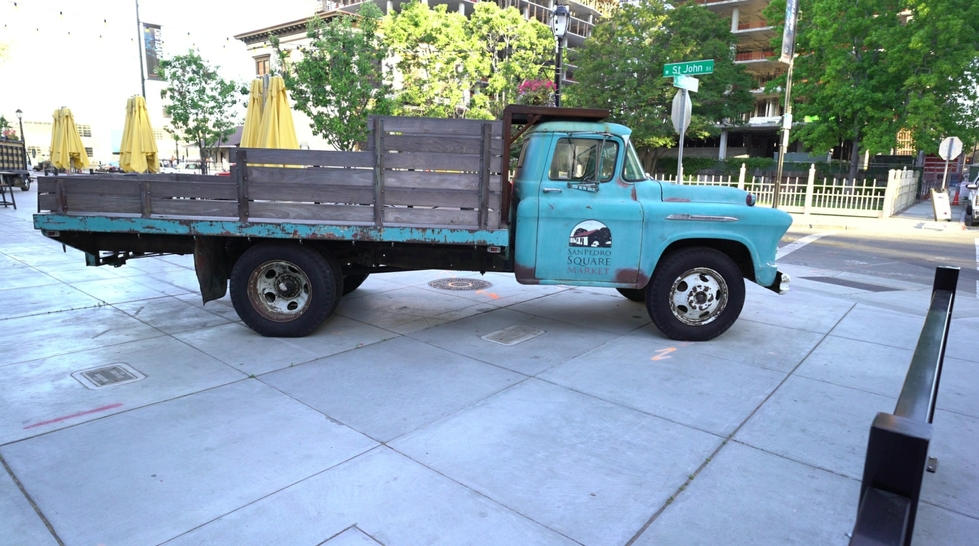

In [8]:
camera, image_path = sfm_dataset[0]
print(camera.to_slang())
image = Image.open(image_path)
image

# Projection

## Dispatch Projection Kernel

In [9]:
# Create a buffer for the Gaussian2D points.
gaussian2d_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_gaussian_2d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian2d_buf

Buffer(
  device = 0x117ccff68,
  size = 6700288,
  struct_size = 64,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 6.39 MB,
  label = 
)

In [10]:
# Create flag buffer for culling.
inside_flag_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.g_inside_flag,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
inside_flag_buf

Buffer(
  device = 0x117ccff68,
  size = 418768,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 408.95 kB,
  label = 
)

In [11]:
ker_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("project")])
)
ker_proj

ComputeKernel(0x32a14af90)

In [12]:
ker_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_3d_buf,
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf
    }
)

In [13]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d.type_layout.element_type_layout,
    gaussian2d_buf,
)
cursor.element_count
cursor[0]

{'position': {0.3242423, 0.34090775, 0.003679035}, 'covariance': {{8.30109e-06, -1.383993e-13}, {-2.0603591e-13, 2.6687947e-05}}, 'color': {0.27344006, 0.3125016, 0.35546938}, 'opacity': 0.5} [Gaussian2D]

## Cull Gaussians

In [14]:
ker_cull = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("cull")])
)

In [15]:
# Cull the Gaussian points.
inside_offset_buf = prefix_sum(inside_flag_buf)
inside_offset_cursor = spy.BufferCursor(
    program.reflection.g_inside_offset.type_layout.element_type_layout,
    inside_offset_buf,
)
# Read the last element of the cull prefix buffer to get the number of culled points.
num_viewing = int(inside_offset_cursor[len(inside_offset_cursor) - 1].read())  # type: ignore
num_viewing

97155

In [16]:
# Culled gaussians
culled_gaussian_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
culled_gaussian_buf

Buffer(
  device = 0x117ccff68,
  size = 6217920,
  struct_size = 64,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 5.93 MB,
  label = 
)

In [17]:
ker_cull.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_gaussian_2d": gaussian2d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "g_gaussian_2d_culled": culled_gaussian_buf
    }
)

In [18]:
cursor = spy.BufferCursor(
    program.reflection.g_gaussian_2d_culled.type_layout.element_type_layout,
    culled_gaussian_buf,
)
cursor[0]

{'position': {0.3242423, 0.34090775, 0.003679035}, 'covariance': {{8.30109e-06, -1.383993e-13}, {-2.0603591e-13, 2.6687947e-05}}, 'color': {0.27344006, 0.3125016, 0.35546938}, 'opacity': 0.5} [Gaussian2D]

# Tiling

In [19]:
ker_tile = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("computeTile")])
)
ker_build_gs = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("buildGaussianTable")])
)

In [20]:
num_tile_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.g_num_tiles,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
num_tile_buf

Buffer(
  device = 0x117ccff68,
  size = 388620,
  struct_size = 4,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 379.51 kB,
  label = 
)

In [21]:
ker_tile.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles": num_tile_buf
    }
)

In [22]:
num_tile_arr = num_tile_buf.to_numpy().view(np.uint32)
num_table_entries = np.sum(num_tile_arr).item()
num_table_entries

187751

In [23]:
gaussian_table_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_table,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_table_buf

Buffer(
  device = 0x117ccff68,
  size = 3004016,
  struct_size = 16,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 2.86 MB,
  label = 
)

In [24]:
num_tile_prefix_buf = prefix_sum(num_tile_buf)

In [25]:
ker_build_gs.dispatch(
    thread_count=[num_viewing, 1, 1],
    numViewing=num_viewing,
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_num_tiles_prefix": num_tile_prefix_buf,
        "g_gaussian_table": gaussian_table_buf,
    }
)

# Sort Tile

In [26]:
numpy_sort(gaussian_table_buf)

In [27]:
ker_tile_hist = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("tileHistogram")])
)

In [28]:
hist_buf = device.create_buffer(
    element_count=2**8,
    struct_type=program.reflection.g_tile_hist_atomic,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)
# Compute the histogram of the Gaussian table.
ker_tile_hist.dispatch(
    thread_count=[num_table_entries, 1, 1],
    numEntries=num_table_entries,
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "g_tile_hist_atomic": hist_buf,
    },
)

[WARN] (rhi) slang: metal 32023.620: /Users/fangjun/Documents/stanford/gslang/src/gslang/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.



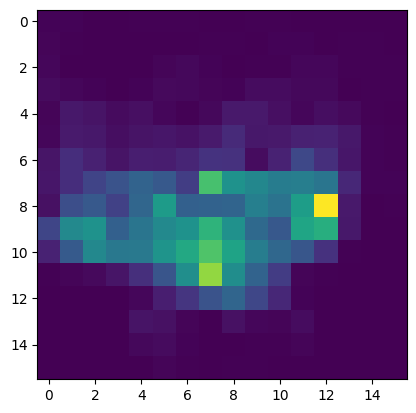

In [29]:
plt.imshow(hist_buf.to_numpy().view(np.uint32).reshape(16, 16))

# Rasterize

In [30]:
ker_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("duplicateGaussian")])
)
ker_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("rasterize")])
)

In [31]:
gaussian_2d_sorted_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.g_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
gaussian_2d_sorted_buf

Buffer(
  device = 0x117ccff68,
  size = 12016064,
  struct_size = 64,
  format = undefined,
  usage = (shader_resource | unordered_access),
  memory_type = device_local,
  memory_usage = 11.46 MB,
  label = 
)

In [32]:
ker_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_2d_culled": culled_gaussian_buf,
        "g_gaussian_table": gaussian_table_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf
    }
)

In [33]:
render_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

depth_target = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

num_depth_buf = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.r32_uint,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [34]:
hist_arr = hist_buf.to_numpy().view(np.uint32)
hist_offs = np.zeros_like(hist_arr)
hist_offs[1:] = np.cumsum(hist_arr)[:-1]

In [35]:
tile_offst_buf = device.create_buffer(
    element_count=len(hist_offs),
    struct_type=program.reflection.g_tile_offs,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)
tile_offst_buf.copy_from_numpy(hist_offs)

In [36]:
ker_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_depth_target": depth_target,
        "g_num_rendered_gaussians": num_depth_buf,
    }
)

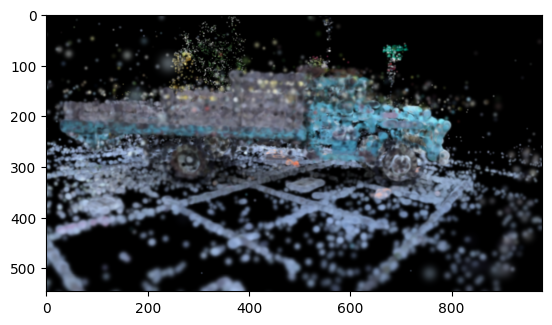

In [37]:
unoptimized_raw_image = jnp.array(render_target.to_numpy()[:, :, :3])
plt.imshow(unoptimized_raw_image)

# Image Loss

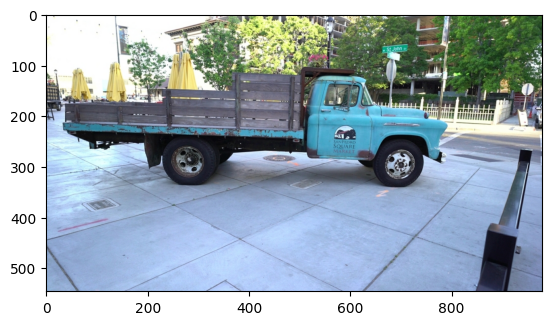

In [38]:
image_arr = jnp.array(image).astype(jnp.float32) / 255.0
plt.imshow(image_arr)

In [39]:
def image_loss(src: jnp.ndarray, dst: jnp.ndarray):
    return jnp.mean((dst - src)**2)

In [40]:
image_loss(unoptimized_raw_image, image_arr)

Array(0.28188264, dtype=float32)

In [41]:
# Image grad.
loss_grad = jax.value_and_grad(image_loss)

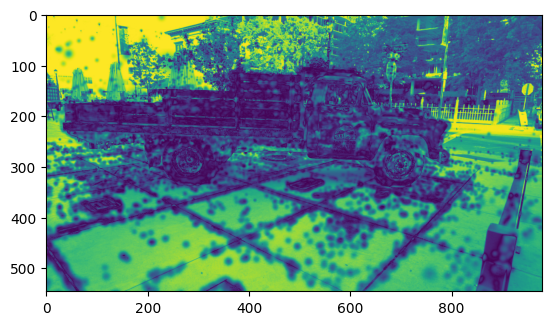

In [42]:
loss, render_target_grad = loss_grad(unoptimized_raw_image, image_arr)
plt.imshow(jnp.linalg.norm(render_target_grad, axis=-1))

In [43]:
render_target_grad.shape

(546, 979, 3)

In [44]:
rg_shape = render_target_grad.shape
render_target_grad = jnp.concatenate((render_target_grad, jnp.zeros((rg_shape[0], rg_shape[1], 1))), axis=-1)
render_target_grad.shape

(546, 979, 4)

# Backward Gradient into Slang

In [45]:
ker_bwd_rasterize = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdRasterize")])
)
ker_bwd_duplicate = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdDuplicateGaussian")])
)
ker_bwd_cull_proj = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("bwdCullProjection")])
)
ker_grad_descent = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("gradDescentGaussian3D")])
)

ker_extract_culled_gaussian = device.create_compute_kernel(
    device.link_program([module], [module.entry_point("extractCulledGaussianGrad")])
)

In [46]:
grad_texture = device.create_texture(
    type=spy.TextureType.texture_2d,
    format=spy.Format.rgba32_float,
    width=camera.sensor_size.x,
    height=camera.sensor_size.y,
    usage=spy.TextureUsage.shader_resource
    | spy.TextureUsage.unordered_access,
)

In [47]:
grad_texture.copy_from_numpy(render_target_grad)

In [48]:
a_gaussian_2d_sorted_grad_buf = device.create_buffer(
    element_count=num_table_entries,
    struct_type=program.reflection.d_a_gaussian_2d_sorted,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

a_gaussian_2d_culled_grad_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.d_a_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

gaussian_2d_culled_grad_buf = device.create_buffer(
    element_count=num_viewing,
    struct_type=program.reflection.d_gaussian_2d_culled,
    usage=spy.BufferUsage.shader_resource
    | spy.BufferUsage.unordered_access,
)

gaussian_3d_grad_buf = device.create_buffer(
    element_count=len(gaussians),
    struct_type=program.reflection.d_gaussian_3d,
    usage=spy.BufferUsage.shader_resource | spy.BufferUsage.unordered_access,
)

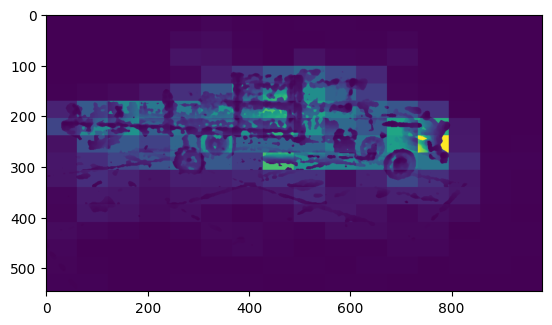

In [49]:
num_depth_buf.to_numpy().view(np.uint32)
plt.imshow(num_depth_buf.to_numpy().view(np.uint32))

In [50]:
ker_bwd_rasterize.dispatch(
    thread_count=[camera.sensor_size.x, camera.sensor_size.y, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_tile_hist": hist_buf,
        "g_tile_offs": tile_offst_buf,
        "g_gaussian_2d_sorted": gaussian_2d_sorted_buf,
        "g_render_target": render_target,
        "g_num_rendered_gaussians": num_depth_buf,
        "d_render_target": grad_texture,
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        
    }
)

#bwd duplicate
ker_bwd_duplicate.dispatch(
    thread_count=[num_table_entries, 1, 1],
    vars={
        "g_gaussian_table": gaussian_table_buf,
        "d_a_gaussian_2d_sorted": a_gaussian_2d_sorted_grad_buf,
        "d_a_gaussian_2d_culled": a_gaussian_2d_culled_grad_buf,
    }
)

# Extract the gradients for the culled Gaussian 2D points.
ker_extract_culled_gaussian.dispatch(
    thread_count=[num_viewing, 1, 1],
    vars={
        "d_gaussian_2d_culled": gaussian_2d_culled_grad_buf,
        "d_a_gaussian_2d_culled": a_gaussian_2d_culled_grad_buf,
    }
)


# bwd cull and projection
ker_bwd_cull_proj.dispatch(
    thread_count=[len(gaussians), 1, 1],
    vars={
        "g_camera": camera.to_slang(),
        "g_gaussian_3d": gaussian_3d_buf,
        "g_inside_flag": inside_flag_buf,
        "g_inside_offset": inside_offset_buf,
        "d_gaussian_2d_culled": gaussian_2d_culled_grad_buf,
        "d_gaussian_3d": gaussian_3d_grad_buf,
    }
)

[WARN] (rhi) slang: /Users/fangjun/Documents/stanford/gslang/src/gslang/slang/./renderer/rasterizer.slang(145): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
        d_a_gaussian_2d_sorted[i][(j + tid.x) % 11].add(d[(j + tid.x) % 11]);
                                                       ^
/Users/fangjun/Documents/stanford/gslang/src/gslang/slang/./renderer/rasterizer.slang(150): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
          d_a_gaussian_2d_sorted[i][(j + gid.x) % 11].add(sum);
                                                         ^
metal 32023.620: /Users/fangjun/Documents/stanford/gslang/src/gslang/slang/./renderer/rasterizer.slang(145): warning :  unused variable '_S104' [-Wunused-variable]
                float _S104 = atomic_fetch_add_explicit(&(*((&kernelContext_0)->d_a_gaussian_2d_sorted_0+i_0))[_S103], _S102[_S103], memory_order_relaxed);
  

In [51]:
arr = a_gaussian_2d_sorted_grad_buf.to_numpy().view(np.float32).reshape(num_table_entries, -1)
np.max(arr, axis=0), np.min(arr, axis=0)

(array([1.3310968e-02, 8.6391186e-03, 0.0000000e+00, 1.7527456e+00,
        2.6316607e-01, 2.6316607e-01, 5.7075143e-01, 1.8674973e-05,
        2.0332247e-05, 1.7347387e-05, 6.5891152e-05], dtype=float32),
 array([-9.5513612e-03, -8.3388407e-03,  0.0000000e+00, -4.3795147e+00,
        -3.4292385e-01, -3.4292385e-01, -1.2897131e+00, -1.1635848e-04,
        -1.3757260e-04, -1.6567505e-04, -4.2315887e-04], dtype=float32))

In [52]:
arr = a_gaussian_2d_culled_grad_buf.to_numpy().view(np.float32).reshape(num_viewing, -1)
np.max(arr, axis=0), np.min(arr, axis=0)

(array([1.0826070e-02, 4.5276703e-03, 0.0000000e+00, 2.0452762e+00,
        2.6316613e-01, 2.6316613e-01, 6.4105731e-01, 1.5074800e-05,
        1.7276618e-05, 1.5072853e-05, 7.7056910e-05], dtype=float32),
 array([-9.5513612e-03, -7.6551056e-03,  0.0000000e+00, -4.3795147e+00,
        -3.4292385e-01, -3.4292385e-01, -1.3607750e+00, -2.2145669e-04,
        -2.2655014e-04, -2.2736948e-04, -9.9312374e-04], dtype=float32))

In [53]:
arr = gaussian_3d_grad_buf.to_numpy().view(np.float32).reshape(len(gaussians), -1, 4)[:, :5, :]
np.max(arr, axis=0), np.min(arr, axis=0)

(array([[2.7607388e-03, 7.9540396e-03, 2.3964869e-03, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.4715148e-04],
        [4.7111276e-05, 2.3304647e-05, 3.1598197e-06, 0.0000000e+00],
        [3.5011576e-06, 4.3188898e-06, 3.2291298e-06, 0.0000000e+00],
        [1.9264227e-05, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],
       dtype=float32),
 array([[-6.4628157e-03, -2.1551049e-03, -4.1922904e-03,  0.0000000e+00],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, -2.3823471e-03],
        [-4.6055068e-04, -6.4463093e-04, -8.5991909e-05,  0.0000000e+00],
        [-3.2086275e-05, -3.1511776e-05, -3.1305575e-05,  0.0000000e+00],
        [-2.4828094e-04,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00]],
       dtype=float32))

## A Very Simple Gradient Descent

In [54]:
import logging
logging.basicConfig(level=logging.WARN)

In [55]:
from gslang.renderer import Renderer
from tqdm.auto import tqdm

renderer = Renderer(gaussians, camera)

In [56]:
num_epoch = 1
init_lr = 1e-4
current_lr = init_lr
decay_steps = 8
gamma = 0.95

indices = np.random.permutation(len(sfm_dataset))

for epoch in range(num_epoch):
    print(f"Epoch {epoch+1}/{num_epoch}")
    running_loss = 0.0

    pbar = tqdm(indices, desc="it", leave=False)
    for i, idx in enumerate(pbar, start=1):
        renderer.zero_grad()

        camera, image_path = sfm_dataset[idx]
        renderer.camera = camera
        image = Image.open(image_path)

        loss = renderer.render(gt_image=image)
        running_loss += loss

        renderer.backward(
            pos_lr=current_lr,
            rot_lr=current_lr*10,
            scale_lr=current_lr*10,
            color_lr=current_lr,
            opacity_lr=current_lr,
            sh_lr=current_lr,
            beta1=0.95,
            beta2=0.999,
            weight_decay=1e-4
        )

        renderer.optimizer_step()

        pbar.set_description(f"loss={loss:.4f}, lr={current_lr:.1e}")

    avg_loss = running_loss / len(sfm_dataset)
    print(f"  Epoch {epoch+1} avg loss: {avg_loss:.6f}")

Epoch 1/1


it:   0%|          | 0/251 [00:00<?, ?it/s]

[WARN] (rhi) slang: metal 32023.620: /Users/fangjun/Documents/stanford/gslang/src/gslang/slang/./renderer/tile.slang(75): warning :  unused variable '_S1' [-Wunused-variable]
    uint _S1 = atomic_fetch_add_explicit((&kernelContext_0)->g_tile_hist_atomic_0+uint(((*((&kernelContext_0)->g_gaussian_table_0+tid_1)).key_0) >> 32U), 1U, memory_order_relaxed);
         ^
1 warning generated.

[WARN] (rhi) slang: /Users/fangjun/Documents/stanford/gslang/src/gslang/slang/./renderer/rasterizer.slang(145): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
        d_a_gaussian_2d_sorted[i][(j + tid.x) % 11].add(d[(j + tid.x) % 11]);
                                                       ^
/Users/fangjun/Documents/stanford/gslang/src/gslang/slang/./renderer/rasterizer.slang(150): error 55204: intrinsic operation 'floating point atomic operation' is not supported for the current target.
          d_a_gaussian_2d_sorted[i][(j + gid.x) % 11].ad

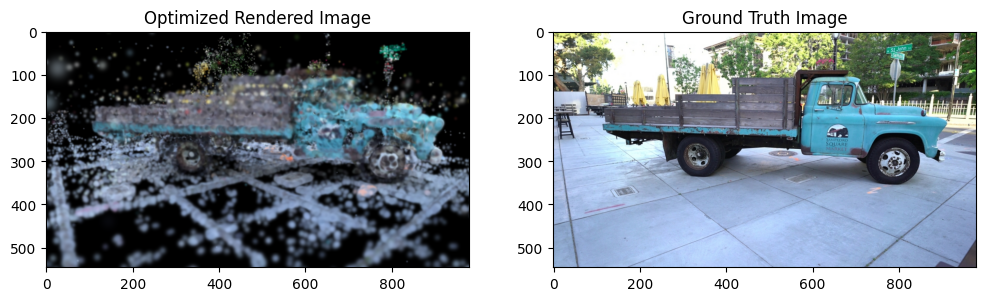

In [57]:
#render
camera, image_path = sfm_dataset[2]
image = Image.open(image_path)

renderer.camera = camera
renderer.render()

render_target = renderer.render_target
raw_image = jnp.array(render_target.to_numpy()[:, :, :3])

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(raw_image)
ax[0].set_title("Optimized Rendered Image")
ax[1].imshow(jnp.array(image).astype(jnp.float32) / 255.0)
ax[1].set_title("Ground Truth Image")
plt.show()

In [58]:
# Get the gaussian buffer.
grad_buf = renderer.gaussian_3d_buf
# Get the cursor to the gradient buffer.'
gaussian_3d_grad_cursor = spy.BufferCursor(
    program.reflection.d_gaussian_3d.type_layout.element_type_layout,
    grad_buf,
)
len(gaussian_3d_grad_cursor)

104692

In [59]:
# Draw a histogram of the alpha gradients.
alpha = []
for i in range(len(gaussian_3d_grad_cursor)):
    g = gaussian_3d_grad_cursor[i].read()
    alpha.append(g["opacity"])
alpha = np.array(alpha, dtype=np.float32)


(array([1.000e+00, 1.000e+00, 1.000e+00, 4.000e+00, 5.000e+00, 8.000e+00,
        7.000e+00, 6.000e+00, 1.500e+01, 2.900e+01, 3.400e+01, 5.600e+01,
        7.600e+01, 8.300e+01, 1.160e+02, 1.460e+02, 2.220e+02, 2.910e+02,
        3.390e+02, 4.370e+02, 6.230e+02, 7.230e+02, 8.060e+02, 9.500e+02,
        1.019e+03, 1.146e+03, 1.134e+03, 1.247e+03, 1.307e+03, 1.427e+03,
        1.446e+03, 1.468e+03, 1.659e+03, 1.598e+03, 1.570e+03, 1.699e+03,
        1.677e+03, 1.761e+03, 1.734e+03, 1.735e+03, 1.784e+03, 1.823e+03,
        1.751e+03, 1.764e+03, 1.797e+03, 1.724e+03, 1.745e+03, 1.770e+03,
        1.770e+03, 1.787e+03, 1.842e+03, 1.838e+03, 1.936e+03, 2.020e+03,
        2.167e+03, 2.078e+03, 2.204e+03, 2.240e+03, 2.396e+03, 2.486e+03,
        2.462e+03, 2.482e+03, 2.544e+03, 2.515e+03, 2.430e+03, 2.202e+03,
        2.166e+03, 2.051e+03, 1.908e+03, 1.670e+03, 1.548e+03, 1.630e+03,
        1.477e+03, 1.452e+03, 1.315e+03, 1.182e+03, 1.024e+03, 9.750e+02,
        8.290e+02, 7.140e+02, 5.870e+0

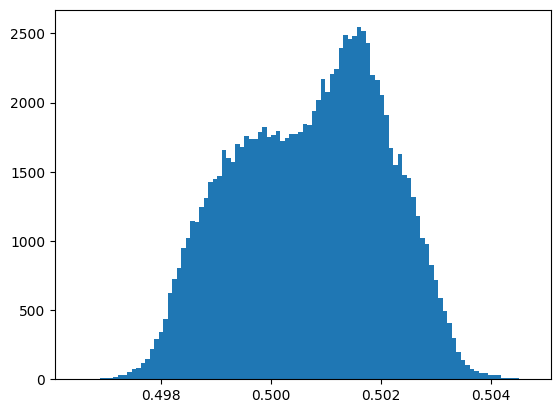

In [60]:
sigmoid = lambda x: 1 / (1 + np.exp(-x))
plt.hist(sigmoid(alpha), bins=100)

In [61]:
# Get the gradient buffer for the Gaussian 2D points.
gaussian_3d_grad_buf = renderer.gaussian_3d_grad_buf
gaussian_3d_grad_cursor = spy.BufferCursor(
    program.reflection.d_gaussian_3d.type_layout.element_type_layout,
    gaussian_3d_grad_buf,
)
len(gaussian_3d_grad_cursor)

104692

(array([9.8814e+04, 2.9470e+03, 9.8300e+02, 4.8500e+02, 2.9300e+02,
        2.0000e+02, 1.7200e+02, 1.2200e+02, 1.0300e+02, 9.0000e+01,
        7.1000e+01, 6.2000e+01, 4.3000e+01, 3.5000e+01, 2.5000e+01,
        2.4000e+01, 3.0000e+01, 2.1000e+01, 2.3000e+01, 1.7000e+01,
        1.5000e+01, 1.6000e+01, 1.5000e+01, 1.5000e+01, 7.0000e+00,
        7.0000e+00, 1.0000e+01, 4.0000e+00, 5.0000e+00, 2.0000e+00,
        7.0000e+00, 3.0000e+00, 2.0000e+00, 6.0000e+00, 4.0000e+00,
        2.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00, 2.0000e+00,
        1.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

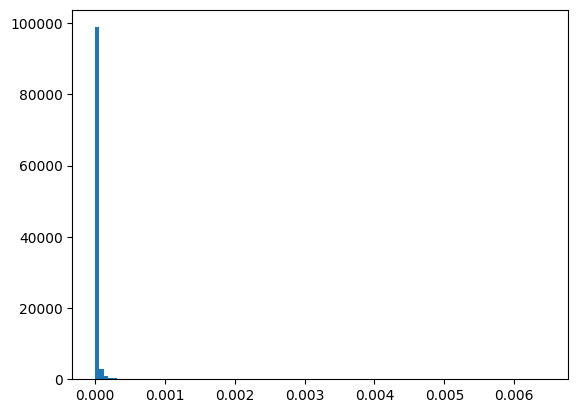

In [62]:
# Draw a histogram of the position gradients length.
position_grad = []
for i in range(len(gaussian_3d_grad_cursor)):
    g = gaussian_3d_grad_cursor[i].read()
    pos_grad = glm.vec3(list(g["position"]))
    position_grad.append(glm.length(pos_grad))
position_grad = np.array(position_grad, dtype=np.float32)
plt.hist(position_grad, bins=100)

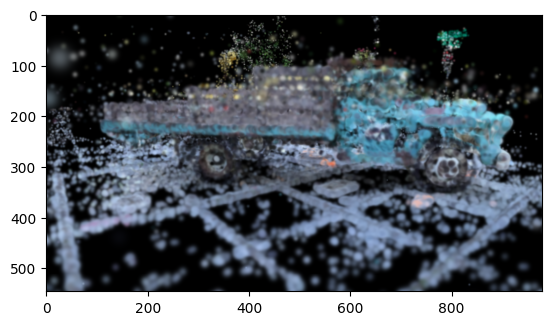

In [63]:
renderer.render()
plt.imshow(jnp.array(render_target.to_numpy()[:, :, :3]))

In [64]:
renderer.render(
    gt_image=image,
    use_densify=True
)

Array(0.2488757, dtype=float32)

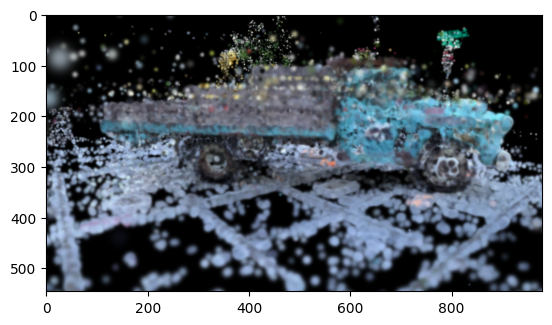

In [65]:
renderer.render()
plt.imshow(jnp.array(render_target.to_numpy()[:, :, :3]))